In [1]:
import os
import numpy as np
from astropy import units as u
from astropy.io import fits
from astropy.wcs import WCS
from math import factorial
import matplotlib.pyplot as plt
import corner
import matplotlib as mpl
import scipy
import yaml

import tools
import models_afixed as models
import initial_params_afixed as initial_params

import emcee
#from pixell import enmap, bunch
import multiprocess
from multiprocess import Pool

In [2]:
def get_config_file(config_file):
    with open(config_file, 'r') as stream:
        try:
            config_data = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)
    return config_data

def log_prior (var):
        
    if fit_method == 'gnfw_circ+beta_circ':      
        x_sub, y_sub, rs_main, rc_sub, beta_main, gamma_main, beta_sub,\
        A_main, A_sub, a_bkg = var #x_main, y_main, 
        
        #x_main_in[0] < x_main < x_main_in[1] and \
        #y_main_in[0] < y_main < y_main_in[1] and \
        if x_sub_in[0] < x_sub < x_sub_in[1] and \
        y_sub_in[0] < y_sub < y_sub_in[1] and \
        rs_main_in[0] < rs_main < rs_main_in[1] and \
        rc_sub_in[0] < rc_sub < rc_sub_in[1] and \
        beta_main_in[0] < beta_main < beta_main_in[1] and \
        gamma_main_in[0] < gamma_main < gamma_main_in[1] and \
        beta_sub_in[0] < beta_sub < beta_sub_in[1] and \
        A_main_in[0] < A_main < A_main_in[1] and \
        A_sub_in[0] < A_sub < A_sub_in[1] and \
        a_bkg_in[0] < a_bkg < a_bkg_in[1]: 
            return 0.0
        else:
            return -np.inf
        
def log_likelihood (var):            
    
    if fit_method == 'gnfw_circ+beta_circ':      
        x_main, y_main, x_sub, y_sub, rs_main, rc_sub, alpha_main, beta_main, gamma_main, beta_sub, \
        A_main, A_sub, a_bkg = var #x_main, y_main,
        
        mod_main = models.GNFW_model_cluster_circ(x, y, x_main, y_main, rs_main, beta_main, alpha_main, gamma_main, A_main)
        mod_sub = models.beta_model_cluster_circ(x, y, x_sub, y_sub, rc_sub, beta_sub, A_sub)
        
        map_model = models.exp(1, exp_main_map)*(tools.convolve(mod_main, psf_main_map)) +\
                    models.exp(1, exp_sub_map)*(tools.convolve(mod_sub, psf_sub_map)) +\
                    models.bkg(a_bkg, bkg_map)
    
    
    c = np.nansum(map_model - map_data*np.log(map_model)) + c0
    
    #print('c = ', c)
    
    return -0.5*c

                
def log_posterior (var):
    
    lp = log_prior(var)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(var)

In [5]:
cfg = get_config_file('./config_MOO1142_afixed.yaml')

# Select the fitting method (here some examples of combinations of models for cls and bridge, see models.py)
fit_method = cfg['fit_method']
# Folder with the map
path = cfg['data']['gen_path']
prova_num= cfg['save_fit']['prova_num']  # Number/Name of this check

# Important numbers to run the fit
Nwalkers= int(cfg['Nwalkers'])  # Number of point you want to generate for each step. It must be 4-5 times the number of parameters
Nsamples=int(cfg['Nsamples']) # Number of iterations you want to run
Nsteps=int(cfg['Nsteps'])  # Check the autocorrelation time every Nsteps
chain_length=int(cfg['chain_length'])  # the chain must be longer 'chain_length' times the autocorrelation time
N_check=int( Nsamples/Nsteps)  # Number of checks that will be performed
coeff_burn=int(cfg['coeff_burn'])  # Burn the first coeff_burn*np.max(tau) iterations
ncores=int(multiprocess.cpu_count()/2) - 10 # Number of cores used for parallelization

###############################################################################
###############################################################################

# Create the folders for the results 
path_res = path + 'fit/' + fit_method + prova_num + '/'
if os.path.isdir(path_res)==False:
	os.mkdir(path_res)
print(path_res)
print('Num samples: ', Nsamples)
# Open the map 
map_name = cfg['data']['map_file']
psf_main_name = cfg['data']['psf_main_file']
psf_sub_name = cfg['data']['psf_sub_file']
exp_main_name = cfg['data']['exp_main_file']
exp_sub_name = cfg['data']['exp_sub_file']
bkg_name = cfg['data']['bkg_file']

map_file=fits.open(path + map_name)
psf_main_file=fits.open(path + psf_main_name)
psf_sub_file=fits.open(path + psf_sub_name)
exp_main_file=fits.open(path + exp_main_name)
#wcs_north = WCS(exp_north_file[0].header)
exp_sub_file=fits.open(path + exp_sub_name)
#wcs_south = WCS(exp_south_file[0].header)
bkg_file=fits.open(path + bkg_name)


header=map_file[0].header
wcs=WCS(header)
map_data = map_file[0].data
map_data = map_data.astype(float)
psf_main_map=psf_main_file[0].data
psf_sub_map=psf_sub_file[0].data
exp_main_map_raw=exp_main_file[0].data
#Xdim_exp=map_file[0].header['NAXIS1']  
#Ydim_exp=map_file[0].header['NAXIS2']
exp_main_map_norm = exp_main_map_raw /  np.max(exp_main_map_raw)
store_exp_main_norm_factor = np.max(exp_main_map_raw)
exp_sub_map_raw=exp_sub_file[0].data
#Xdim_exp=map_file[0].header['NAXIS1']  
#Ydim_exp=map_file[0].header['NAXIS2']
exp_sub_map_norm = exp_sub_map_raw /  np.max(exp_sub_map_raw)
store_exp_sub_norm_factor = np.max(exp_sub_map_raw)
#Xdim_exp=map_file[0].header['NAXIS1']  
#Ydim_exp=map_file[0].header['NAXIS2']

#set the pixel with zero exposure to nan
e_min = cfg['min_exposure']
exp_main_map = np.where(exp_main_map_norm>e_min, exp_main_map_norm, np.nan)
exp_main_map = exp_main_map.astype(float)
exp_sub_map = np.where(exp_sub_map_norm>e_min, exp_sub_map_norm, np.nan)
exp_sub_map = exp_sub_map.astype(float)

bkg_map=bkg_file[0].data
#Xdim_bkg=map_file[0].header['NAXIS1']  
#Ydim_bkg=map_file[0].header['NAXIS2']
bkg_map = bkg_map.astype(float)

if fit_method=='gnfw_circ+beta_circ':
    min_x = min(np.shape(map_data)[0], np.shape(bkg_map)[0])
    min_y = min(np.shape(map_data)[1], np.shape(bkg_map)[1])
    min_dim = min(min_x, min_y)
    map_data = map_data[:min_dim, :min_dim]
    exp_main_map = exp_main_map[:min_dim, :min_dim]
    exp_sub_map = exp_sub_map[:min_dim, :min_dim]
    bkg_map = bkg_map[:min_dim, :min_dim]
    Xdim=min_dim 
    Ydim=min_dim
else:
    Xdim=map_file[0].header['NAXIS1']  
    Ydim=map_file[0].header['NAXIS2']

dim_pix=cfg['dim_pixel']*u.deg.to('arcmin')  # pixel size in arcmin = 0.04167 arcmin

def logfact(n):
    #fucntion to calculate ln(n!)
    if n == 0:
        return 0
    elif n == 1:
        return 0
    else:
        fact = np.sqrt(2*np.pi*n)*(n/np.e)**n
        return np.log(n)

logfact = np.vectorize(logfact)

c0 = 2*np.nansum(logfact(map_data))
print('c0 = ', c0)

# Create the map for the model
x = np.arange(0, Xdim, 1)
y = np.arange(0, Ydim, 1)
x,y = np.meshgrid(x,y)

alpha_main_fix = 1.0510
gamma_main_fix = 2*0.3081
x_main_fix = 53.58
y_main_fix = 40.18

/home/eleobar/MOO1142/alpha_fixed/fit/gnfw_circ+beta_circ_afixed_initsampleNOTrestart/
Num samples:  10000
c0 =  5204


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-END to 58839.579120 from DATE-END'. [astropy.wcs.wcs]


In [15]:
filename_chain = 'chain.h5'
backend = emcee.backends.HDFBackend(path_res+filename_chain)
samples = backend.get_chain()
print('SHAPE CHAIN:', np.shape(samples))
print('LEN CHAIN:', len(samples))

SHAPE CHAIN: (10000, 100, 10)
LEN CHAIN: 10000


In [9]:
likelihood = []
likelihood_walker1 = []

from tqdm import tqdm
for step in tqdm(range(len(samples))):
    var_med = np.mean(samples[step], axis=0)
    var_walker1 = samples[step][1]
    likelihood.append(log_likelihood(var_med))
    likelihood_walker1.append(log_likelihood(var_walker1))


100%|██████████| 10000/10000 [1:17:04<00:00,  2.16it/s]


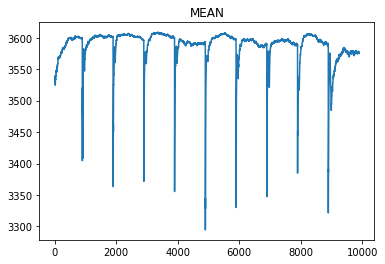

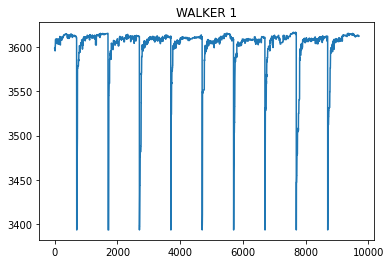

In [18]:
plt.plot(likelihood[100:])
plt.title('MEAN')
plt.show()

plt.plot(likelihood_walker1[300:])
plt.title('WALKER 1')
plt.show()

In [7]:
var = np.array(np.copy(samples[0]))
med = np.mean(var, axis=0)
print(np.shape(med))

#cstat = -2*log_likelihood(samples)

(10,)


In [6]:
path_nuovo = '/home/eleobar/MOO1142/all_free/fit/gnfw_circ+beta_circ_allfree_1/'
filename_chain = 'chain.h5'
backend = emcee.backends.HDFBackend(path_nuovo+filename_chain)
samples = backend.get_chain()
print('SHAPE CHAIN:', np.shape(samples))
print('LEN CHAIN:', len(samples))

likelihood = []
likelihood_walker1 = []

from tqdm import tqdm
for step in tqdm(range(len(samples))):
    var_med = np.mean(samples[step], axis=0)
    var_walker1 = samples[step][1]
    likelihood.append(log_likelihood(var_med))
    likelihood_walker1.append(log_likelihood(var_walker1))

SHAPE CHAIN: (3800, 100, 13)
LEN CHAIN: 3800


100%|██████████| 3800/3800 [28:25<00:00,  2.23it/s]


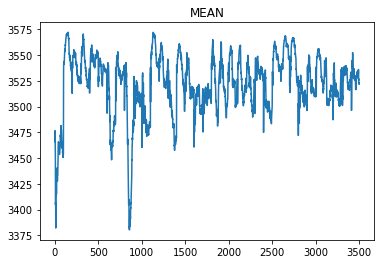

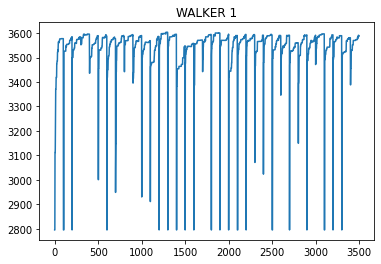

In [7]:
plt.plot(likelihood[300:])
plt.title('MEAN')
plt.show()

plt.plot(likelihood_walker1[300:])
plt.title('WALKER 1')
plt.show()